# Go Academics — ML Track Notebook
**Author:** NGAMIJE RUHUMULIZA Davy  
**Supervisor:** Emmanuel Adjei  
**Institution:** African Leadership University (ALU)  
**Date:** June 2026

---

This notebook documents the machine learning pipeline for **Go Academics** — a context-aware, offline-capable system that predicts secondary school students' academic risk in Rwanda.

It covers three sections:
1. **Data Visualization & Engineering** — distributions, correlations, feature engineering
2. **Model Architecture** — Logistic Regression, Random Forest, XGBoost
3. **Initial Performance Metrics** — accuracy, recall, F1, AUC-ROC, confusion matrix

> **Dataset:** real anonymized records from Excella Secondary School Rwanda (School A), Term 1 — `data/raw/excella_school_a_term1.csv`, 151 rows, stream "Grade 10", subjects English and French. This is the primary (Plan A) dataset; current scope is one school, one term. The UCI Student Performance Dataset (Plan B) is kept as an inactive fallback — see `docs/plan_b.md` — and is no longer used here.

> **Small-sample caveat:** 151 rows from a single school/term is a small dataset. Metrics below (especially cross-validation std. dev.) should be read as preliminary, not production-grade guarantees. They will firm up as more terms/schools are collected.

## 1. Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Style
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#f8fafc',
                     'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False})
BLUE   = '#1E3A5F'
AMBER  = '#F59E0B'
RED    = '#EF4444'
GREEN  = '#22C55E'

print('Setup complete.')

Setup complete.


## 2. Data Visualization & Engineering

### 2.1 Load Dataset

In [31]:
DATA_PATH = Path('..') / 'data' / 'processed' / 'students.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'\nColumn types:')
print(df.dtypes)
df.head()

Dataset shape: (151, 11)

Column types:
StudentID          object
School             object
Gender             object
Stream             object
Term                int64
Subject            object
CA_Score          float64
Exam_Score        float64
Attendance_Pct    float64
Final_Result       object
CA_Trend          float64
dtype: object


,StudentID,School,Gender,Stream,Term,Subject,CA_Score,Exam_Score,Attendance_Pct,Final_Result,CA_Trend
0,S001,School A,Male,Grade 10,1,English,18.1,44.2,85.9,Pass,0.0
1,S001,School A,Male,Grade 10,1,French,22.0,52.9,85.9,Pass,0.0
2,S002,School A,Male,Grade 10,1,English,14.1,33.6,79.3,Fail,0.0
3,S002,School A,Male,Grade 10,1,French,17.4,40.6,79.3,Pass,0.0
4,S003,School A,Male,Grade 10,1,English,16.2,40.8,75.5,Pass,0.0


In [32]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nClass distribution:')
print(df['Final_Result'].value_counts())
print(f'\nPass rate: {(df["Final_Result"]=="Pass").mean()*100:.1f}%')

Missing values:
StudentID         0
School            0
Gender            0
Stream            0
Term              0
Subject           0
CA_Score          0
Exam_Score        0
Attendance_Pct    0
Final_Result      0
CA_Trend          0
dtype: int64

Class distribution:
Final_Result
Pass    106
Fail     45
Name: count, dtype: int64

Pass rate: 70.2%


### 2.2 Class Distribution (Target Variable)

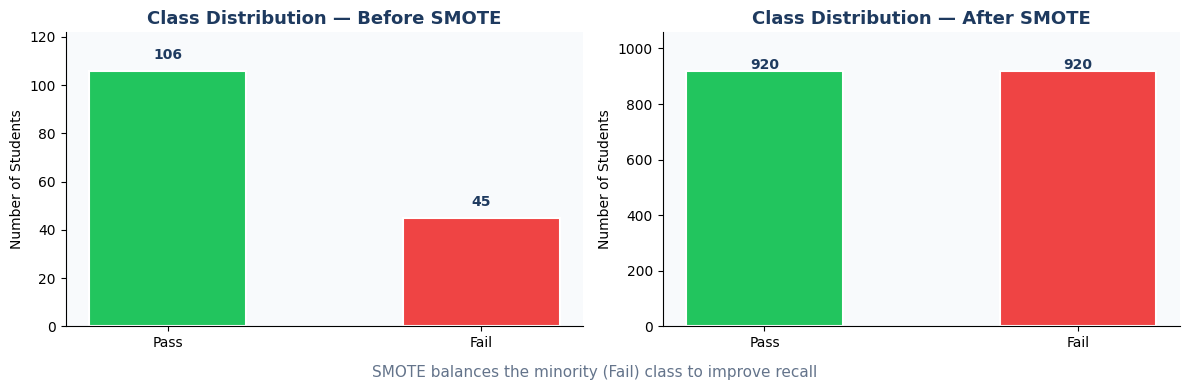

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
counts = df['Final_Result'].value_counts()
colors = [GREEN, RED]
axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution — Before SMOTE', fontsize=13, fontweight='bold', color=BLUE)
axes[0].set_ylabel('Number of Students')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold', color=BLUE)
axes[0].set_ylim(0, counts.max() * 1.15)

# After SMOTE
ml_path = Path('..') / 'data' / 'processed' / 'students_ml.csv'
df_ml = pd.read_csv(ml_path)
smote_counts = df_ml['Final_Result'].value_counts()
labels = ['Pass', 'Fail']
vals   = [smote_counts.get(1, 0), smote_counts.get(0, 0)]
axes[1].bar(labels, vals, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[1].set_title('Class Distribution — After SMOTE', fontsize=13, fontweight='bold', color=BLUE)
axes[1].set_ylabel('Number of Students')
for i, val in enumerate(vals):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold', color=BLUE)
axes[1].set_ylim(0, max(vals) * 1.15)

plt.suptitle('SMOTE balances the minority (Fail) class to improve recall', 
             fontsize=11, color='#64748b', y=0)
plt.tight_layout()
plt.savefig('../docs/fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Feature Distributions

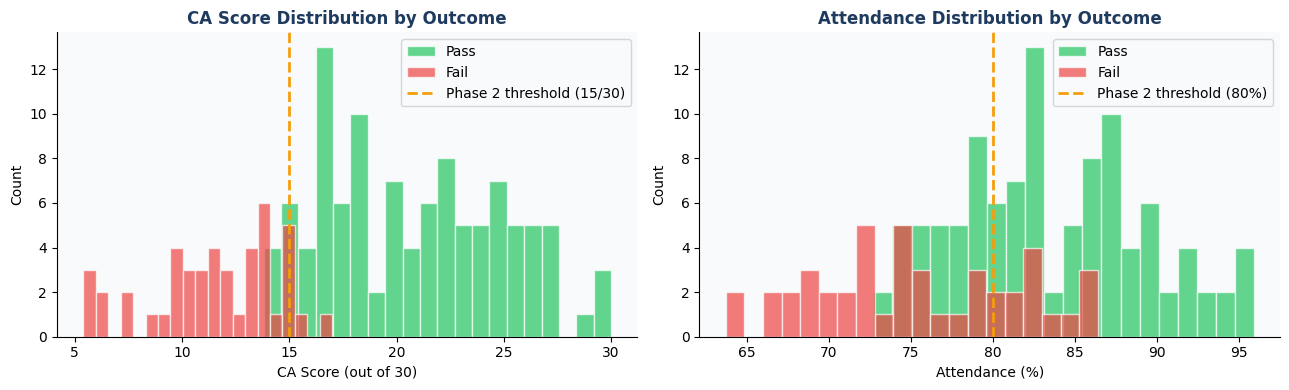

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pass_df = df[df['Final_Result'] == 'Pass']
fail_df = df[df['Final_Result'] == 'Fail']

# CA Score distribution
axes[0].hist(pass_df['CA_Score'], bins=20, alpha=0.7, color=GREEN, label='Pass', edgecolor='white')
axes[0].hist(fail_df['CA_Score'], bins=20, alpha=0.7, color=RED,   label='Fail', edgecolor='white')
axes[0].axvline(15, color=AMBER, linestyle='--', linewidth=2, label='Phase 2 threshold (15/30)')
axes[0].set_title('CA Score Distribution by Outcome', fontsize=12, fontweight='bold', color=BLUE)
axes[0].set_xlabel('CA Score (out of 30)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Attendance distribution
axes[1].hist(pass_df['Attendance_Pct'], bins=20, alpha=0.7, color=GREEN, label='Pass', edgecolor='white')
axes[1].hist(fail_df['Attendance_Pct'], bins=20, alpha=0.7, color=RED,   label='Fail', edgecolor='white')
axes[1].axvline(80, color=AMBER, linestyle='--', linewidth=2, label='Phase 2 threshold (80%)')
axes[1].set_title('Attendance Distribution by Outcome', fontsize=12, fontweight='bold', color=BLUE)
axes[1].set_xlabel('Attendance (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Pass/Fail Rate by Category

> Note: `School` and `Stream` currently have only one value each ("School A", "Grade 10") since this phase covers a single school and stream — those two panels will show a single bar until more schools/streams are collected. `Gender` and `Subject` (English/French) still show real variation.

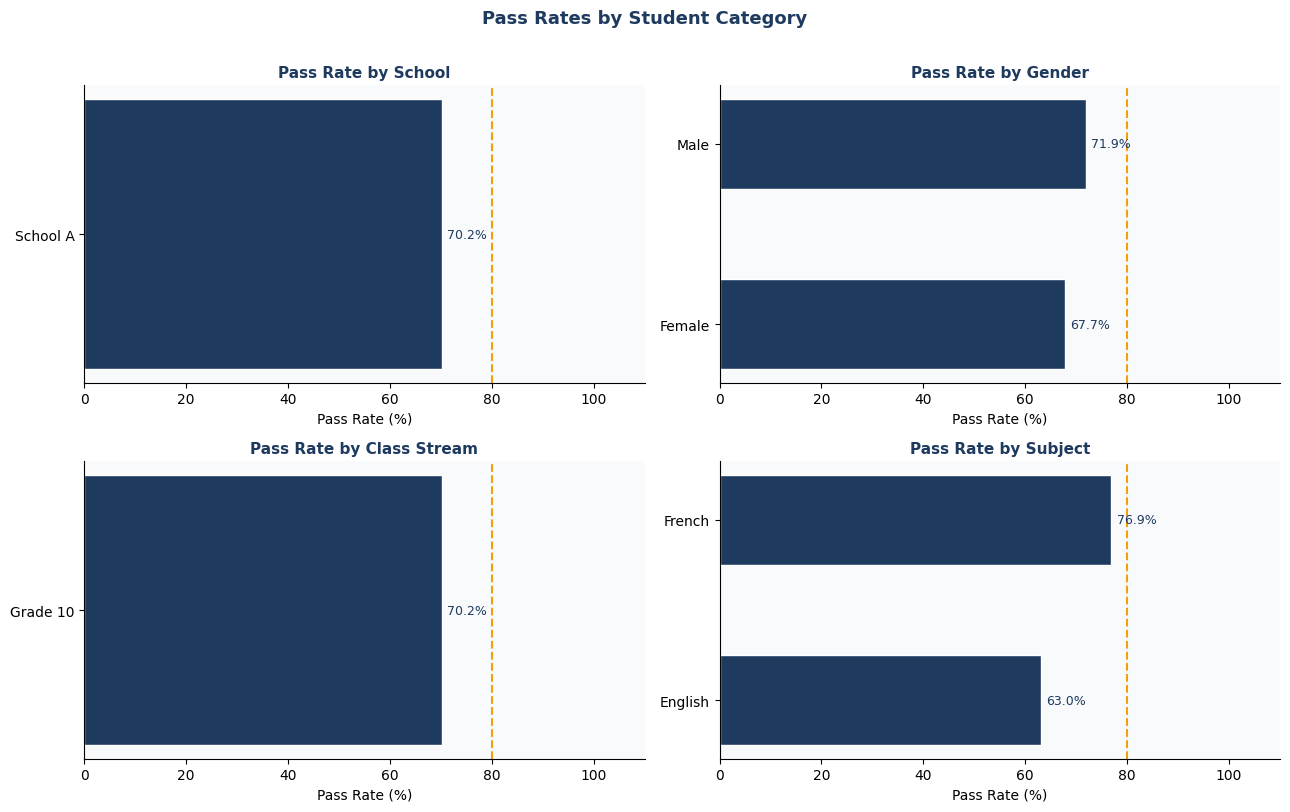

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

cat_cols = [('School', 'School'), ('Gender', 'Gender'),
            ('Stream', 'Class Stream'), ('Subject', 'Subject')]

for ax, (col, label) in zip(axes.flat, cat_cols):
    rates = df.groupby(col)['Final_Result'].apply(
        lambda x: (x == 'Pass').mean() * 100
    ).sort_values()
    bars = ax.barh(rates.index, rates.values, color=BLUE, edgecolor='white', height=0.5)
    ax.axvline(80, color=AMBER, linestyle='--', linewidth=1.5, label='80% line')
    ax.set_title(f'Pass Rate by {label}', fontsize=11, fontweight='bold', color=BLUE)
    ax.set_xlabel('Pass Rate (%)')
    ax.set_xlim(0, 110)
    for bar, val in zip(bars, rates.values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, color=BLUE)

plt.suptitle('Pass Rates by Student Category', fontsize=13, fontweight='bold', color=BLUE, y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_pass_rates_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Correlation Heatmap

> Note: `CA_Trend` is constant at 0 for every row right now (single-term data — see `data/preprocess.py`), so its correlation with every other feature is undefined (`NaN`). That's expected, not a bug; it will become a real signal once a second term is added.

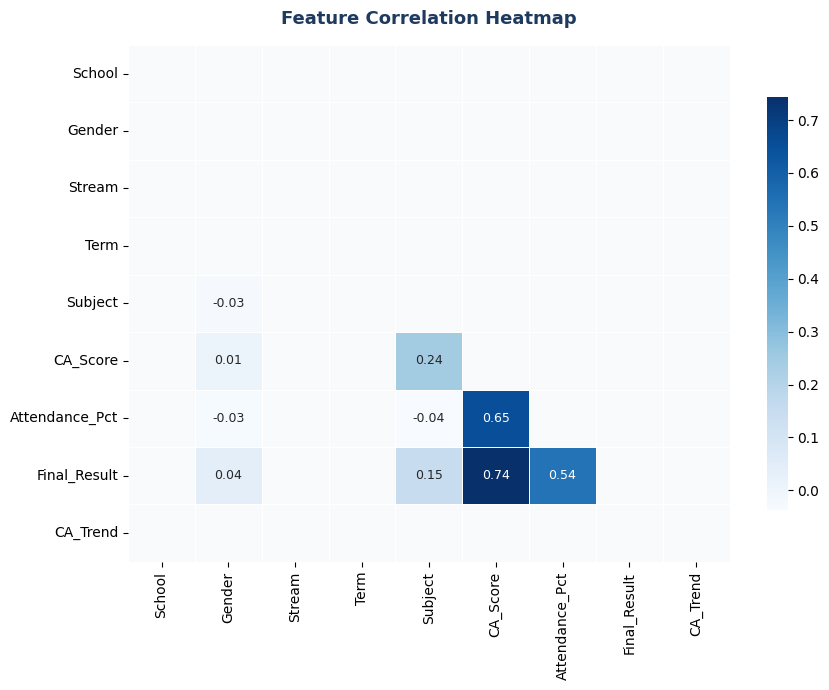


Top correlations with Final_Result:
CA_Score          0.744465
Attendance_Pct    0.541483
Subject           0.151970
Gender            0.044831
School                 NaN
Stream                 NaN
Term                   NaN
CA_Trend               NaN


In [36]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
for col in ['School', 'Gender', 'Stream', 'Subject', 'Final_Result']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
df_enc = df_enc.drop(columns=['StudentID', 'Exam_Score'])

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', color=BLUE, pad=15)
plt.tight_layout()
plt.savefig('../docs/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with Final_Result:')
print(corr['Final_Result'].drop('Final_Result').sort_values(ascending=False).to_string())

### 2.6 CA Score vs Attendance — Risk Scatter

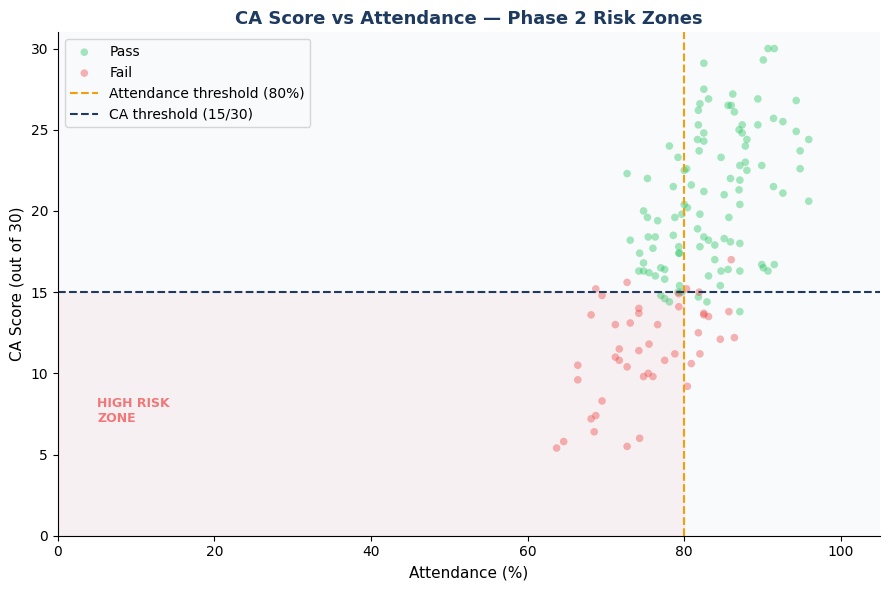

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))

for result, color, label in [('Pass', GREEN, 'Pass'), ('Fail', RED, 'Fail')]:
    subset = df[df['Final_Result'] == result]
    ax.scatter(subset['Attendance_Pct'], subset['CA_Score'],
               c=color, alpha=0.4, s=30, label=label, edgecolors='none')

# Phase thresholds
ax.axvline(80, color=AMBER, linestyle='--', linewidth=1.5, label='Attendance threshold (80%)')
ax.axhline(15, color=BLUE,  linestyle='--', linewidth=1.5, label='CA threshold (15/30)')

# Shade high-risk quadrant
ax.axhspan(0, 15, xmin=0, xmax=(80/105), alpha=0.05, color=RED)

ax.set_xlabel('Attendance (%)', fontsize=11)
ax.set_ylabel('CA Score (out of 30)', fontsize=11)
ax.set_title('CA Score vs Attendance — Phase 2 Risk Zones', fontsize=13, fontweight='bold', color=BLUE)
ax.legend(loc='upper left')
ax.set_xlim(0, 105)
ax.set_ylim(0, 31)
ax.text(5, 7, 'HIGH RISK\nZONE', fontsize=9, color=RED, alpha=0.7, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/fig_risk_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Architecture

Three models are trained and compared. All are standard supervised classification algorithms suited to tabular data.

| Model | Role | Key Hyperparameters |
|---|---|---|
| Logistic Regression | Baseline | `max_iter=1000`, `class_weight=balanced` |
| Random Forest | Primary candidate | `n_estimators=200`, `max_depth=10`, `class_weight=balanced` |
| XGBoost | Primary candidate | `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, `scale_pos_weight` |

**Why these three:**
- Logistic Regression is interpretable and gives a linear baseline
- Random Forest handles non-linear relationships and is robust to imbalance
- XGBoost is state-of-the-art for tabular classification and consistently outperforms on similar datasets (88–92% in literature)

**Evaluation priority: Recall > F1 > Accuracy**  
Missing an at-risk student is worse than a false alarm. The system is designed to over-flag rather than under-flag.

In [38]:
# Load SMOTE-balanced dataset
df_ml = pd.read_csv(Path('..') / 'data' / 'processed' / 'students_ml.csv')

FEATURE_COLS = ['School', 'Gender', 'Stream', 'Term', 'Subject', 'CA_Score', 'Attendance_Pct']
X = df_ml[FEATURE_COLS]
y = df_ml['Final_Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Note: n_estimators reduced to 50 here for demo speed.
# Production model (train.py) uses 200 estimators.
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=50, max_depth=10, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=50, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum()/y_train.sum(),
        random_state=42, eval_metric='logloss', verbosity=0
    ),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'{name} trained.')

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


## 4. Initial Performance Metrics

### 4.1 Metrics Table

In [39]:
rows = []
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv = cross_val_score(model, X, y, cv=StratifiedKFold(3), scoring='recall')
    rows.append({
        'Model':       name,
        'Accuracy':    f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        'Recall':      f"{recall_score(y_test, y_pred)*100:.2f}%",
        'Precision':   f"{precision_score(y_test, y_pred)*100:.2f}%",
        'F1-Score':    f"{f1_score(y_test, y_pred)*100:.2f}%",
        'AUC-ROC':     f"{roc_auc_score(y_test, y_prob)*100:.2f}%",
        'CV Recall':   f"{cv.mean()*100:.2f}% (+/-{cv.std()*100:.2f}%)",
    })

results_df = pd.DataFrame(rows).set_index('Model')
results_df.style.set_caption('Model Performance Comparison (Test Set)').set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#1E3A5F'), ('color', 'white'),
                                   ('font-weight', 'bold'), ('padding', '8px 12px')]},
     {'selector': 'td', 'props': [('padding', '7px 12px'), ('text-align', 'center')]}]
)

,Accuracy,Recall,Precision,F1-Score,AUC-ROC,CV Recall
Model,,,,,,
Logistic Regression,89.67%,89.67%,89.67%,89.67%,96.54%,76.52% (+/-10.89%)
Random Forest,92.66%,92.93%,92.43%,92.68%,97.71%,53.58% (+/-18.33%)
XGBoost,92.12%,92.93%,91.44%,92.18%,97.78%,72.06% (+/-7.96%)


### 4.2 Metrics Bar Chart

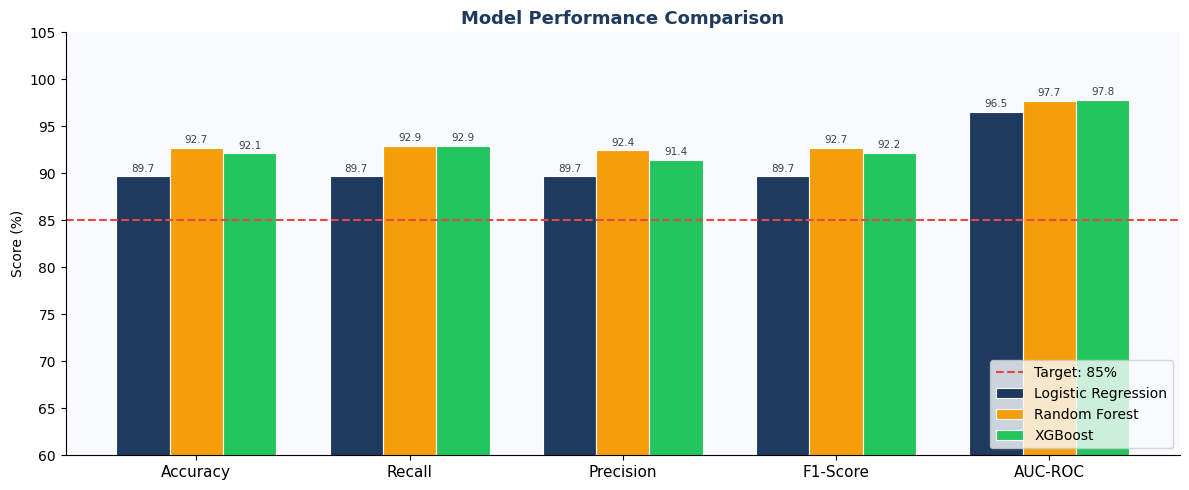

In [40]:
metric_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'AUC-ROC']
model_names  = list(trained.keys())
colors_bar   = [BLUE, AMBER, GREEN]

raw_vals = {}
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    raw_vals[name] = [
        accuracy_score(y_test, y_pred)*100,
        recall_score(y_test, y_pred)*100,
        precision_score(y_test, y_pred)*100,
        f1_score(y_test, y_pred)*100,
        roc_auc_score(y_test, y_prob)*100,
    ]

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, vals) in enumerate(raw_vals.items()):
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors_bar[i], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5, color='#374151')

ax.axhline(85, color=RED, linestyle='--', linewidth=1.5, label='Target: 85%')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(60, 105)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold', color=BLUE)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../docs/fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Confusion Matrices

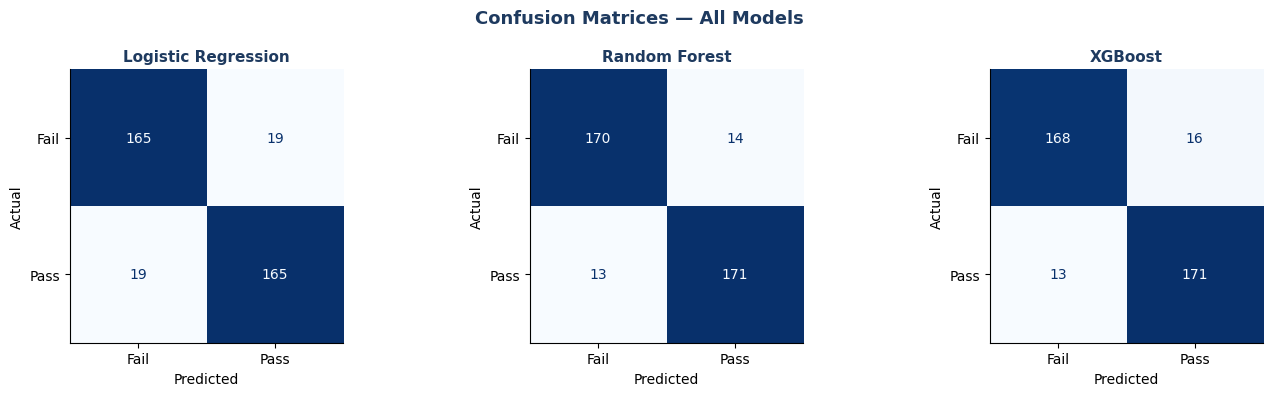

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold', color=BLUE)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig('../docs/fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 ROC Curves

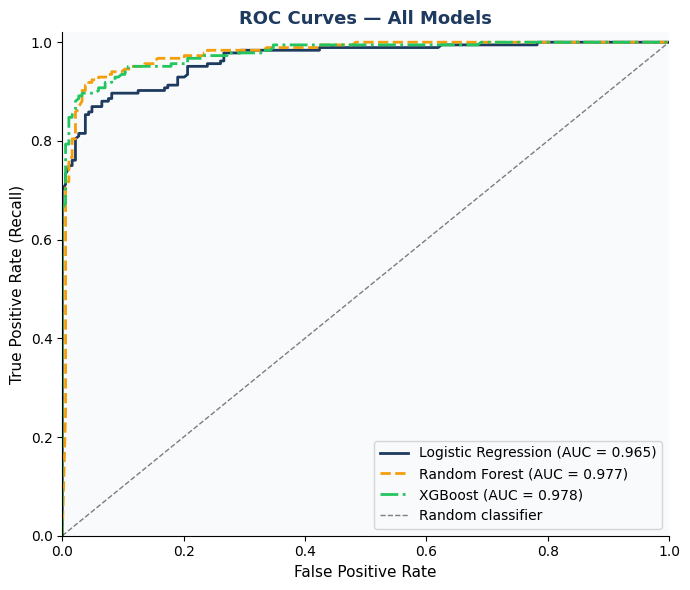

In [42]:
fig, ax = plt.subplots(figsize=(7, 6))

line_styles = ['-', '--', '-.']
line_colors = [BLUE, AMBER, GREEN]

for (name, model), ls, lc in zip(trained.items(), line_styles, line_colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linestyle=ls, color=lc, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', color=BLUE)
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig('../docs/fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Feature Importance (XGBoost)

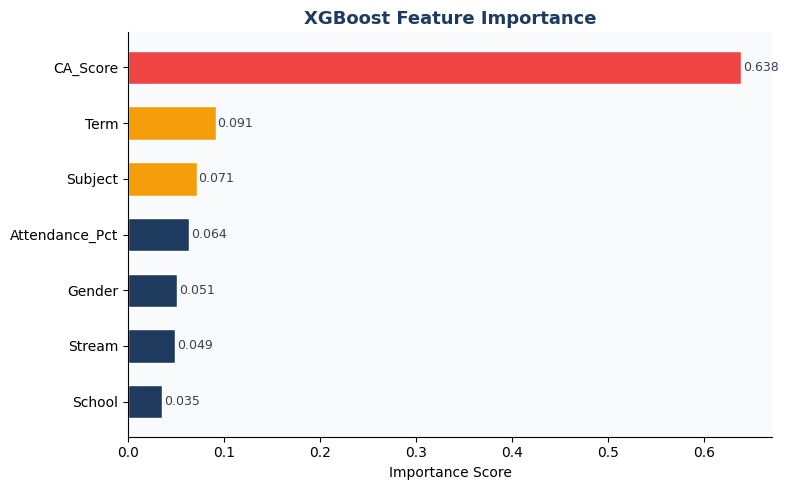


Top features driving risk prediction:
  CA_Score             0.6385
  Term                 0.0911
  Subject              0.0713
  Attendance_Pct       0.0636
  Gender               0.0511
  Stream               0.0491
  School               0.0353


In [43]:
xgb_model = trained['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = [RED if v == importances.max() else
              AMBER if v >= importances.quantile(0.6) else BLUE
              for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_imp,
               edgecolor='white', height=0.6)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#374151')

ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold', color=BLUE)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../docs/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop features driving risk prediction:')
for feat, val in importances.sort_values(ascending=False).items():
    print(f'  {feat:<20} {val:.4f}')

## 5. Summary

See the metrics table in **4.1** and the bar chart in **4.2** for exact figures from this run — they're computed live from `data/processed/students_ml.csv` (the real Excella Secondary School dataset), so don't rely on any hardcoded numbers here.

**Model selection criterion: highest recall, tie-broken by F1** (missing an at-risk student is worse than a false alarm — see `backend/app/ml/train.py::train_models()`). The selected model is saved to `backend/app/ml/saved_models/best_model.pkl` and loaded at runtime for offline inference; `model_meta.json` alongside it has the exact metrics, thresholds, and category encodings from the production training run.

**Small-sample caveat:** this run uses 151 real rows (212 after SMOTE) from one school, one term — noticeably smaller than a typical benchmark dataset. Treat cross-validation standard deviation and any single model's edge over another as preliminary rather than conclusive; re-run and re-evaluate as more terms/schools are added.

**Current scope:** Excella Secondary School Rwanda (anonymized as "School A"), Term 1 only. There is no School B and no Term 2/3 data yet — `CA_Trend` is flat at 0 for every student until a second term is collected (see the note in 2.5).